In [17]:
library(tidyverse)
library(glue)

In [18]:
sessionInfo()

R version 4.2.1 (2022-06-23)
Platform: x86_64-apple-darwin13.4.0 (64-bit)
Running under: macOS Big Sur ... 10.16

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/lib/libopenblasp-r0.3.20.dylib

locale:
[1] C/C.UTF-8/C/C/C/C

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] glue_1.7.0      lubridate_1.9.3 forcats_1.0.0   stringr_1.5.1  
 [5] dplyr_1.1.4     purrr_1.0.2     readr_2.1.5     tidyr_1.3.1    
 [9] tibble_3.2.1    ggplot2_3.5.2   tidyverse_2.0.0

loaded via a namespace (and not attached):
 [1] pillar_1.10.2      compiler_4.2.1     RColorBrewer_1.1-3 base64enc_0.1-3   
 [5] tools_4.2.1        bit_4.0.5          digest_0.6.36      uuid_1.2-0        
 [9] timechange_0.3.0   jsonlite_1.8.8     evaluate_1.0.3     lifecycle_1.0.4   
[13] gtable_0.3.6       pkgconfig_2.0.3    rlang_1.1.4        IRdisplay_1.1     
[17] cli_3.6.3          parallel_4.2.1     IRkernel_1.3.2     fastmap_1

In [19]:
fident_window_to_digits <- function(x) {
  rng <- str_match(as.character(x), "\\[?(0?\\.\\d+),\\s*(1|0?\\.\\d+)\\]")
  lo <- as.numeric(rng[, 2])
  hi <- as.numeric(rng[, 3])
  sprintf("%02d%02d", round(lo * 100), round(hi * 100))
}

In [20]:
consensus_to_original <- read_tsv("./data-preparation/global-alignment/combined_alignment_stats.tsv")%>%
    mutate(
        reference_distance = gsub("^(LVE\\d{5}-[RVDB0-9]{4,5})_.*", "\\1", seq1_id),
        index = gsub("^(LVE\\d{5}-[RVDB0-9]{4})_(.*).consensus.ivar", "\\2", seq1_id),
        segment = ifelse(alignment_length > 5000, "L", "S"))
reference_to_original <- read_tsv("./data-preparation/selected-references/selected_references.tsv")%>%
    mutate(reference_distance = glue("{query}-{fident_window_to_digits(fident_window)}"))

contig_table <- read_tsv("viralmetagenome-out/combined/contigs_overview.tsv")

Rows: 265 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (11): alignment_length, comparable_sites, matches, mismatches, mismatch_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 178 Columns: 16
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (4): query, target, segment, fident_window
dbl (12): fident, alnlen, mismatch, gapopen, qstart, qend, qlen, tstart, ten...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 477 Columns: 173
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (24): index, sample, cluster, step, (annotation) subject, (annotation) ...
dbl (148): (annot

In [30]:
consensus_vs_reference <- left_join(
    merge(consensus_to_original, contig_table, by=c("index","reference_distance")),
    reference_to_original, by=c("reference_distance", "segment"), suffix=c("_consensus", "_reference"))%>%
    mutate(
        is_external_reference_scaffold = ifelse(grepl("NODE|k\\d{3}", `(cluster) centroid`), FALSE, TRUE),
        is_RVDB_reference = ifelse(grepl("RVDB", reference_distance), TRUE, FALSE),
        fident = ifelse(is_RVDB_reference, 1, fident),
        # fident = ifelse(is.na(fident), 0, fident)
    )%>%
    filter(sample!="LVE00223") # Sample with multiple complete segments depending on reference used

dim(consensus_vs_reference)

[1] 221 204

In [31]:
head(consensus_vs_reference)

,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatches,mismatch_rate,seq1_length,⋯,qend,qlen,tstart,tend,tlen,evalue,bits,fident_window,is_external_reference_scaffold,is_RVDB_reference
,<chr>,<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
1,LVE00045_cl0_it2,LVE00045-6466,LVE00045-6466_LVE00045_cl0_it2.consensus_ivar,_R_LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,NA,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE
2,LVE00045_cl0_it2,LVE00045-6668,LVE00045-6668_LVE00045_cl0_it2.consensus_ivar,_R_LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,NA,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE
3,LVE00045_cl0_it2,LVE00045-6870,LVE00045-6870_LVE00045_cl0_it2.consensus_ivar,_R_LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,67,3407,100,3347,3402,0,2308,"(0.68,0.7]",FALSE,FALSE
4,LVE00045_cl0_it2,LVE00045-7274,LVE00045-7274_LVE00045_cl0_it2.consensus_ivar,_R_LVE00045-RVDB_LVE00045_cl1_it2.consensus_ivar,3443,1822,1798,33,0.018112,1891,⋯,67,3407,1,3248,3303,0,2512,"(0.72,0.74]",FALSE,FALSE
5,LVE00045_cl0_it2,LVE00045-7476,LVE00045-7476_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl0_it2.consensus_ivar,7264,7240,5903,1,0.000138,7263,⋯,6824,7241,64,6842,7264,0,7994,"(0.74,0.76]",TRUE,FALSE
6,LVE00045_cl0_it2,LVE00045-7678,LVE00045-7678_LVE00045_cl0_it2.consensus_ivar,LVE00045-RVDB_LVE00045_cl0_it2.consensus_ivar,7242,7164,6043,0,0.000000,7164,⋯,6824,7241,1,6754,7164,0,8440,"(0.76,0.78]",TRUE,FALSE


Warning message:
“Removed 110 rows containing missing values or values outside the scale range
(`geom_point()`).”


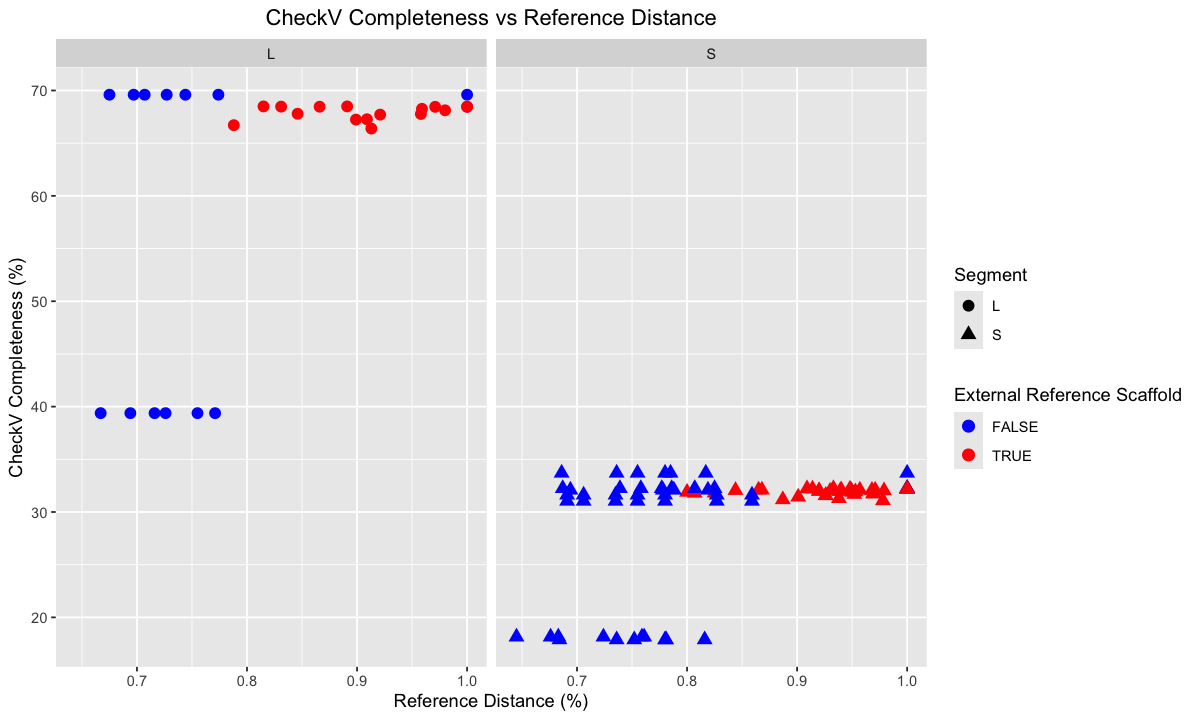

In [32]:
options(repr.plot.width=10, repr.plot.height=6)
ggplot(consensus_vs_reference, aes(x=fident, y=`(checkv) completeness`, color=is_external_reference_scaffold, shape=segment)) +
    geom_point(size=3) +
    facet_wrap(~segment) +
    labs(x="Reference Distance (%)", y="CheckV Completeness (%)", color="External Reference Scaffold", shape="Segment") +
    scale_color_manual(values=c("TRUE"="red", "FALSE"="blue")) +
    ggtitle("CheckV Completeness vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`).”


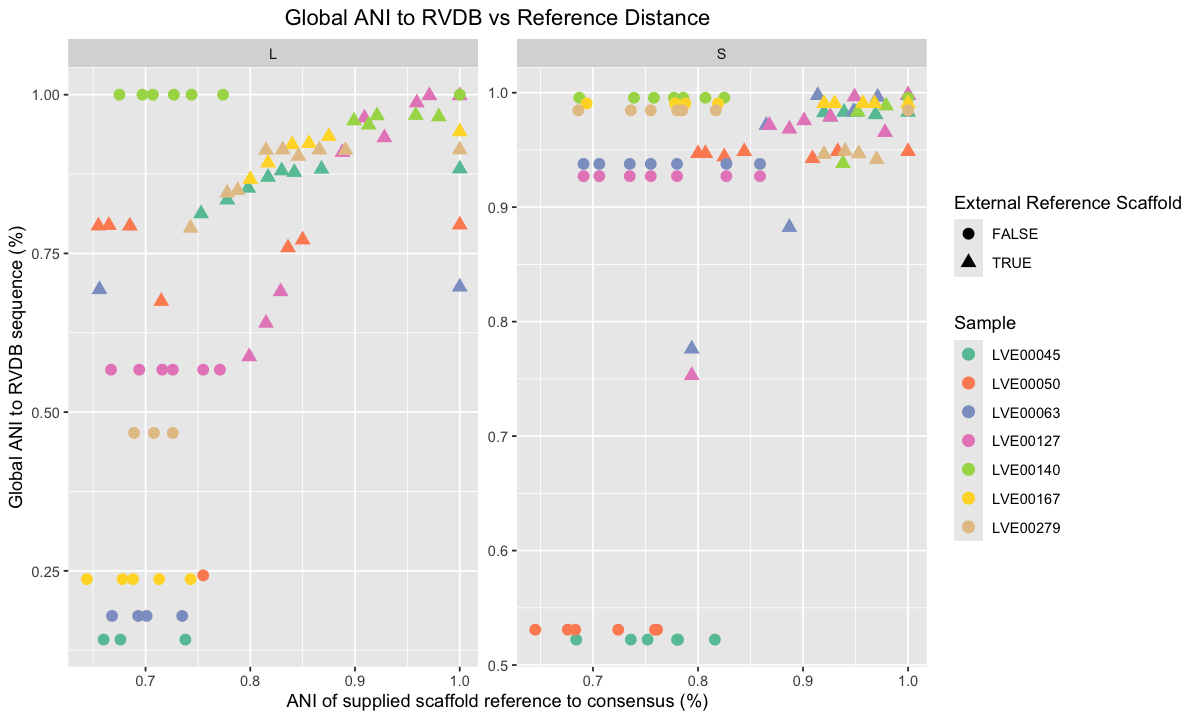

In [33]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches/alignment_length, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="ANI of supplied scaffold reference to consensus (%)", y="Global ANI to RVDB sequence (%)", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 25 rows containing missing values or values outside the scale range
(`geom_line()`).”


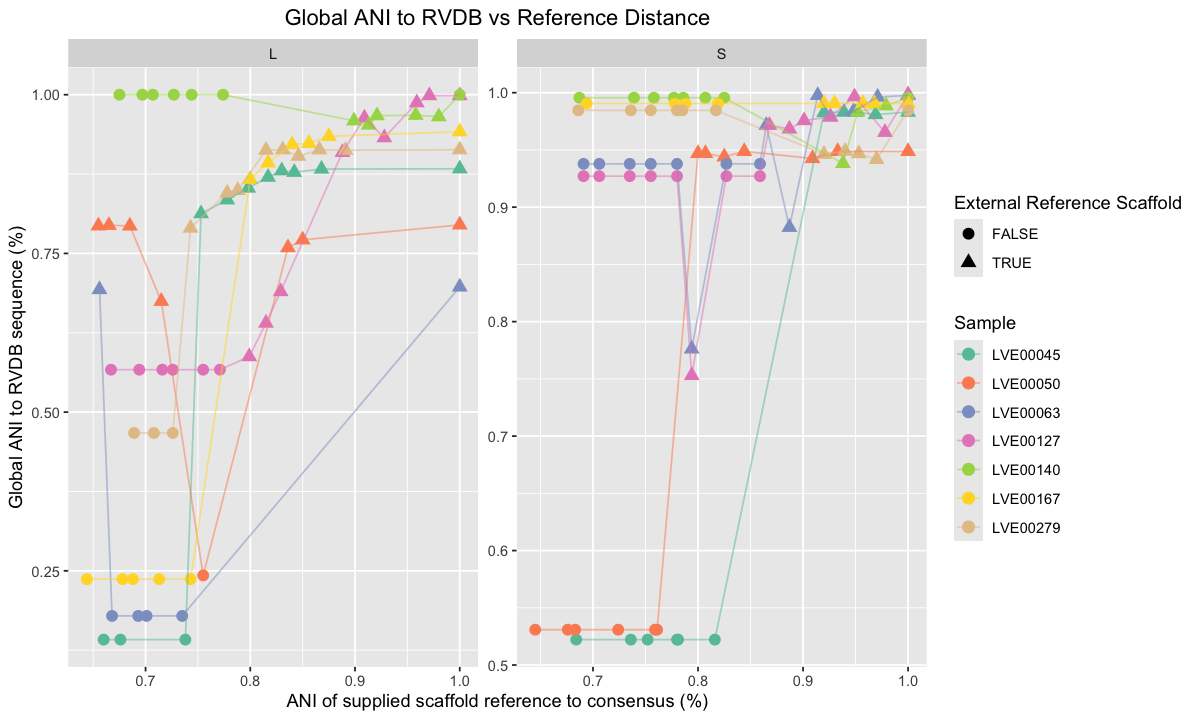

In [40]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches/alignment_length, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    geom_line(aes(group=sample), alpha=0.5) +
    facet_wrap(~segment, scales = "free") +
    labs(x="ANI of supplied scaffold reference to consensus (%)", y="Global ANI to RVDB sequence (%)", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`).”


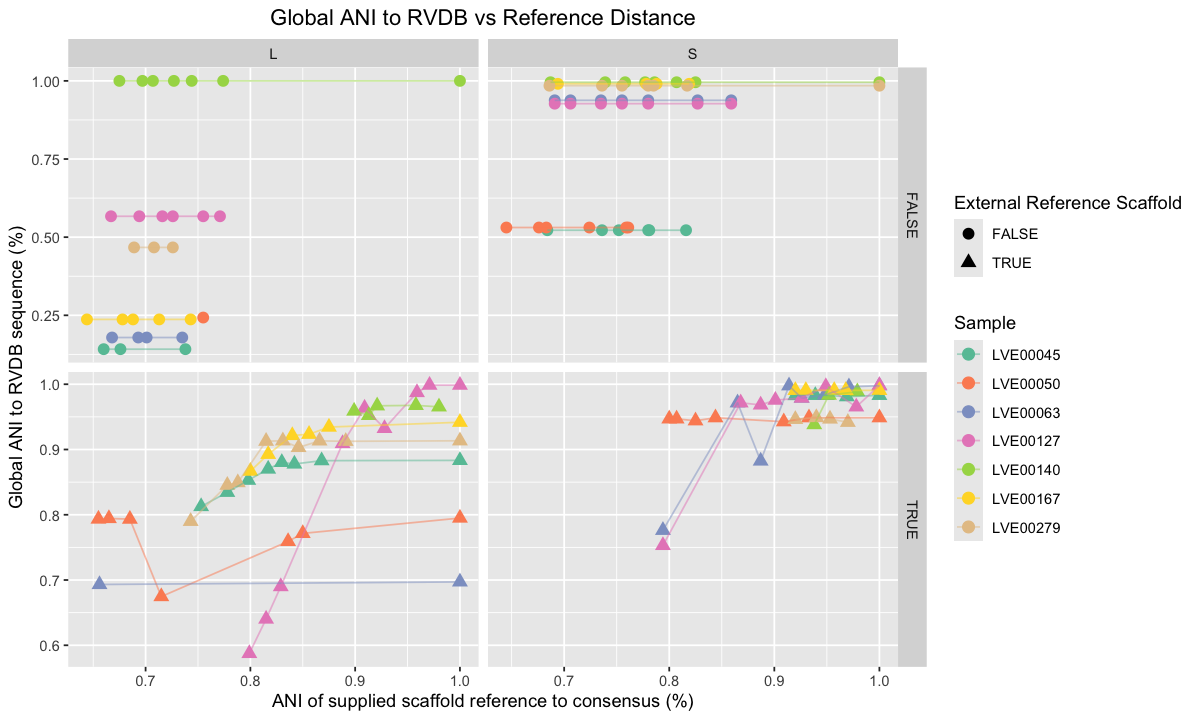

In [42]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches/alignment_length, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    geom_line(aes(group=sample), alpha=0.5) +
    facet_grid(is_external_reference_scaffold~segment, scales = "free") +
    labs(x="ANI of supplied scaffold reference to consensus (%)", y="Global ANI to RVDB sequence (%)", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`).”


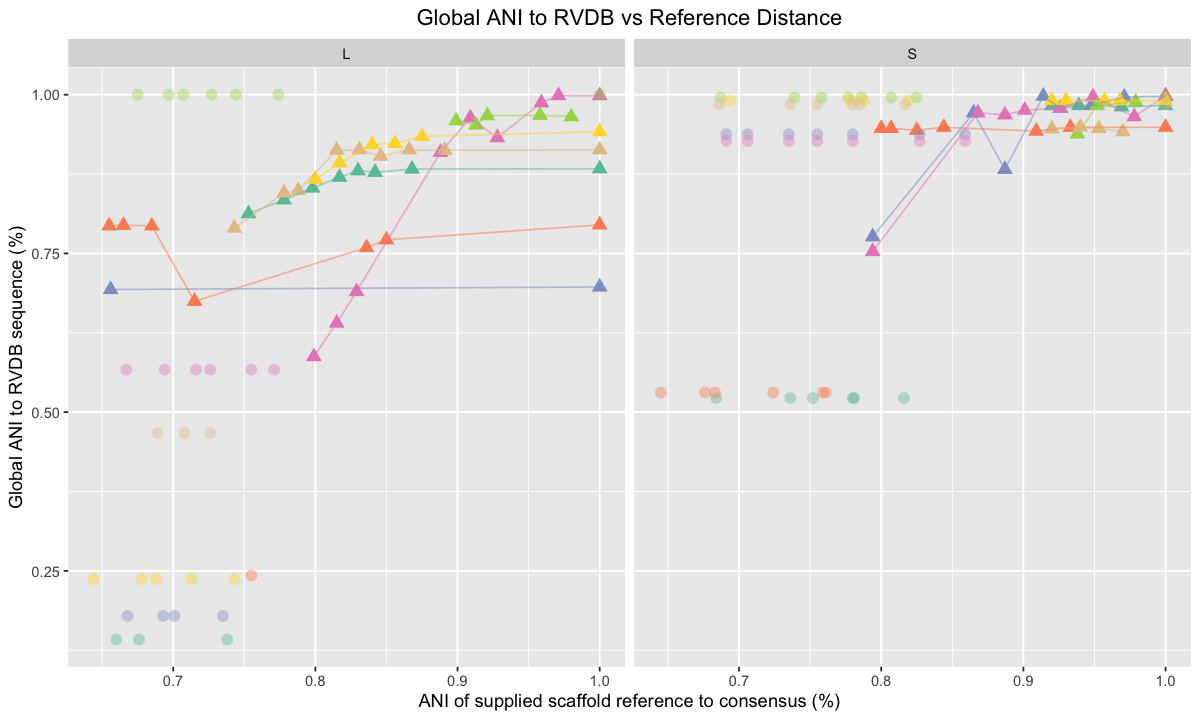

In [64]:
ggplot(consensus_vs_reference, aes(x=fident, y=matches/alignment_length, color=sample,)) +
    geom_point(data = subset(consensus_vs_reference, is_external_reference_scaffold), size=3,  aes(shape= is_external_reference_scaffold)) +
    geom_point(data = subset(consensus_vs_reference, !is_external_reference_scaffold), size=3, aes(shape= is_external_reference_scaffold), alpha=0.4) +
    geom_line(data = subset(consensus_vs_reference, is_external_reference_scaffold), aes(group=sample), alpha=0.5) +
    facet_wrap(~segment) +
    labs(x="ANI of supplied scaffold reference to consensus (%)", y="Global ANI to RVDB sequence (%)", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))+
    theme(legend.position="none")

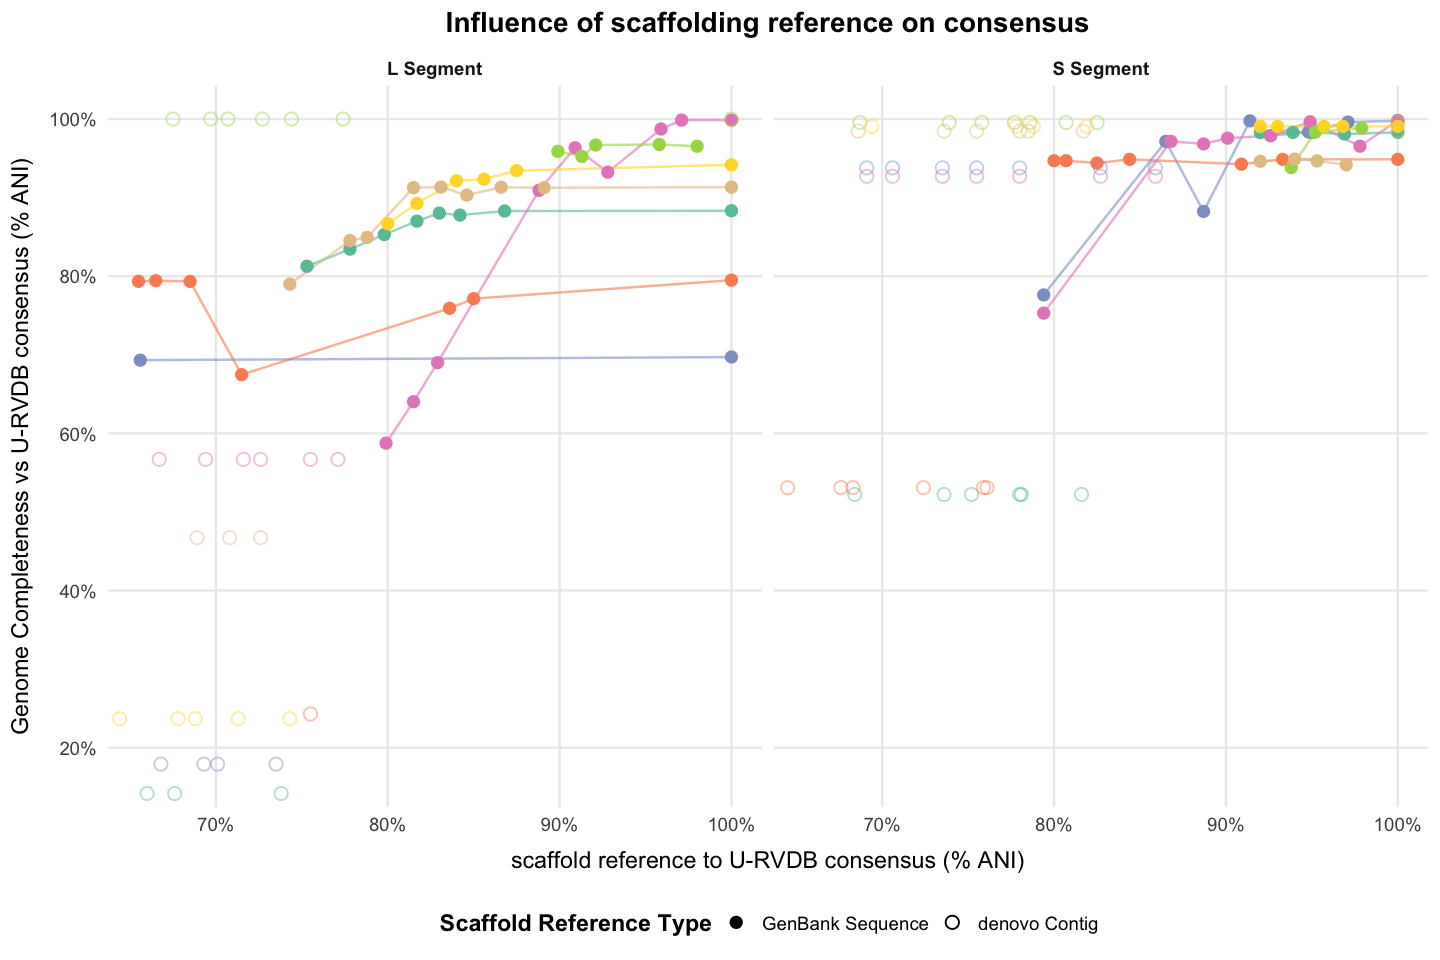

In [ ]:
options(repr.plot.width=12, repr.plot.height=8)
plot_consensus <- consensus_vs_reference %>%
    mutate(
        scaffold_type = if_else(is_external_reference_scaffold, "GenBank Sequence", "denovo Contig"),
        scaffold_type = factor(scaffold_type, levels = c("GenBank Sequence", "denovo Contig")),
        segment = paste(segment, "Segment")
    ) %>%
    tidyr::drop_na(fident, matches, alignment_length)

ggplot(plot_consensus, aes(x = fident, y = matches / alignment_length, color = sample)) +
    geom_line(
        data = filter(plot_consensus, scaffold_type == "GenBank Sequence"),
        aes(group = sample),
        linewidth = 0.7,
        alpha = 0.6
    ) +
    geom_point(
        aes(shape = scaffold_type, alpha = scaffold_type),
        size = 3.2,
        stroke = 0.8
    ) +
    scale_alpha_manual(values = c("GenBank Sequence" = 1, "denovo Contig" = 0.45), guide = "none") +
    scale_shape_manual(
        values = c("GenBank Sequence" = 16, "denovo Contig" = 1),
        guide = guide_legend(title = "Scaffold Reference Type")
    ) +
    scale_color_brewer(palette = "Set2") +
    scale_x_continuous(
        labels = scales::percent_format(accuracy = 1),
        breaks = scales::pretty_breaks(n = 4),
        expand = expansion(mult = c(0.02, 0.05))
    ) +
    scale_y_continuous(
        labels = scales::percent_format(accuracy = 1),
        breaks = scales::pretty_breaks(n = 6),
        expand = expansion(mult = c(0.02, 0.05))
    ) +
    facet_wrap(~segment, nrow = 1) +
    labs(
        x = "scaffold reference to U-RVDB consensus (% ANI)",
        y = "consensus to U-RVDB consensus (% ANI)",
        color = "Sample",
        title = "Influence of scaffolding reference on consensus"
    ) +
    # Turn of color legend
    guides(color = "none") +
    theme_minimal(base_size = 14) +
    # Offset axis titles a little bit
    # Offset space between facets
    theme(
        axis.title.x = element_text(margin = margin(t = 10)),
        axis.title.y = element_text(margin = margin(r = 10)),
        panel.grid.minor = element_blank(),
        strip.text = element_text(face = "bold"),
        legend.position = "bottom",
        legend.box = "horizontal",
        legend.title = element_text(face = "bold"),
        plot.title = element_text(hjust = 0.5, face = "bold")
    )

Warning message:
“Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`).”


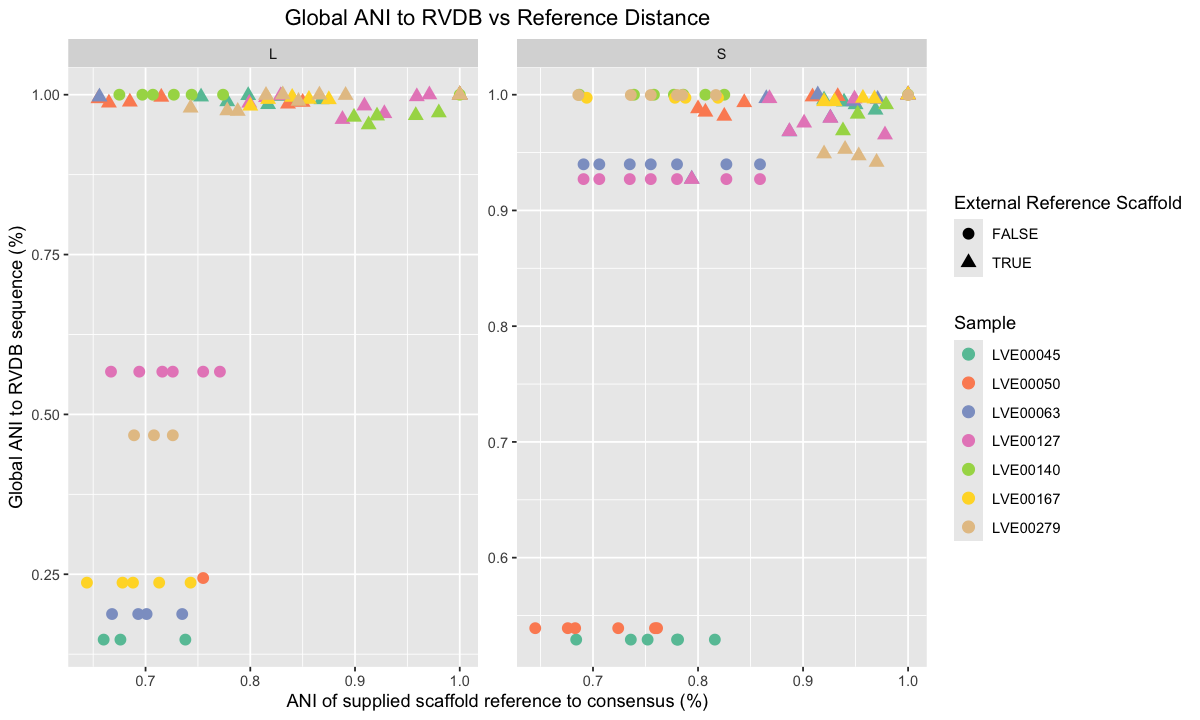

In [34]:
ggplot(consensus_vs_reference, aes(x=fident, y=comparable_sites/alignment_length, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="ANI of supplied scaffold reference to consensus (%)", y="Global ANI to RVDB sequence (%)", color="Sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Global ANI to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

Warning message:
“Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`).”


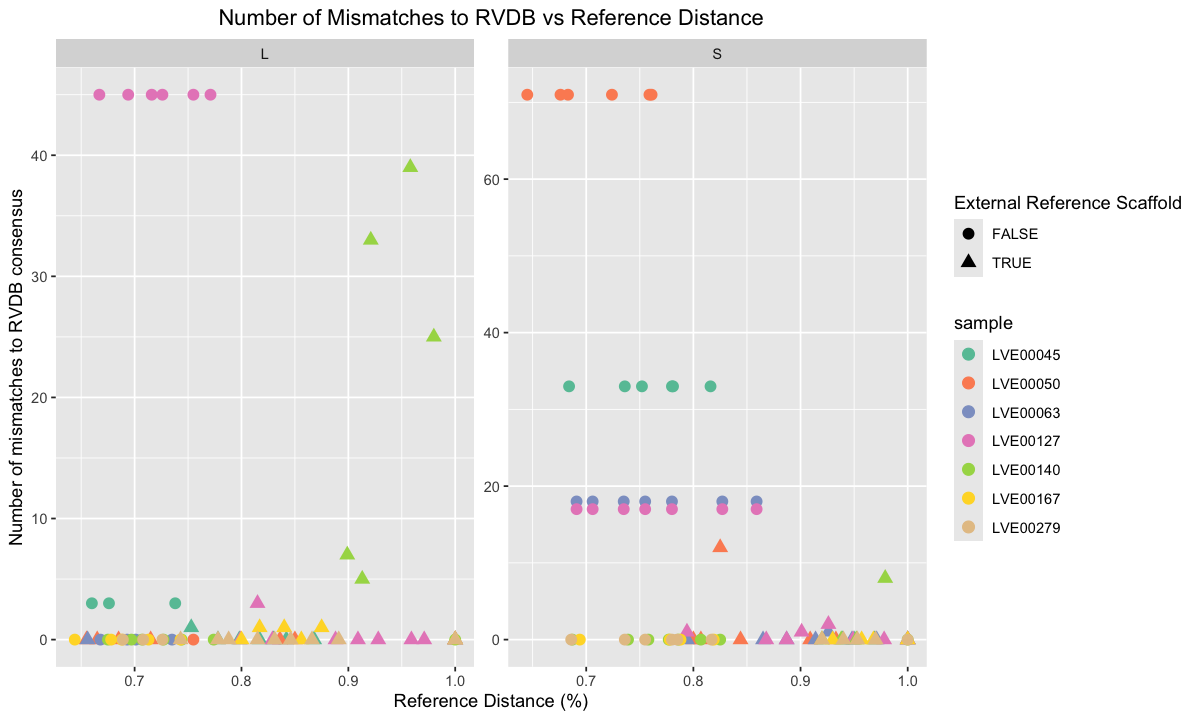

In [35]:
ggplot(consensus_vs_reference, aes(x=fident, y=mismatches,  color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of mismatches to RVDB consensus", color="sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    ggtitle("Number of Mismatches to RVDB vs Reference Distance") +
    theme(plot.title = element_text(hjust = 0.5))

These mismatches, are occuring due to poorly aligned end regions of the sequences, or due to consensus end regions.
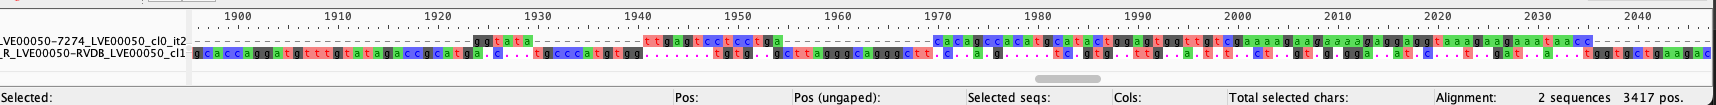
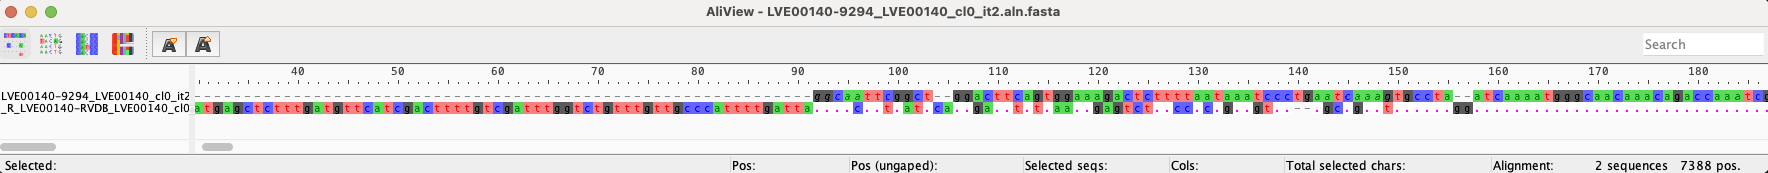


In [37]:
consensus_vs_reference%>%arrange(desc(mismatches))%>%select(mismatches, everything())%>%
    filter(seq1_length > 0.7 * alignment_length)%>%head()

,mismatches,index,reference_distance,seq1_id,seq2_id,alignment_length,comparable_sites,matches,mismatch_rate,seq1_length,⋯,qend,qlen,tstart,tend,tlen,evalue,bits,fident_window,is_external_reference_scaffold,is_RVDB_reference
,<dbl>,<chr>,<glue>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>,<lgl>
1,39,LVE00140_cl0_it2,LVE00140-9496,LVE00140-9496_LVE00140_cl0_it2.consensus_ivar,_R_LVE00140-RVDB_LVE00140_cl0_it2.consensus_ivar,7383,7144,7144,0.005459,7186,⋯,7450,7621,1,7112,7186,0,11649,"(0.94,0.96]",TRUE,FALSE
2,33,LVE00140_cl0_it2,LVE00140-9294,LVE00140-9294_LVE00140_cl0_it2.consensus_ivar,_R_LVE00140-RVDB_LVE00140_cl0_it2.consensus_ivar,7385,7141,7141,0.004621,7179,⋯,7450,7621,41,7155,7180,0,11168,"(0.92,0.94]",TRUE,FALSE
3,25,LVE00140_cl0_it2,LVE00140-9698,LVE00140-9698_LVE00140_cl0_it2.consensus_ivar,_R_LVE00140-RVDB_LVE00140_cl0_it2.consensus_ivar,7393,7185,7137,0.003479,7223,⋯,7449,7621,41,7154,7224,0,12123,"(0.96,0.98]",TRUE,FALSE
4,18,LVE00063_cl0_it2,LVE00063-6668,LVE00063-6668_LVE00063_cl0_it2.consensus_ivar,_R_LVE00063-RVDB_LVE00063_cl1_it2.consensus_ivar,3442,3235,3228,0.005564,3286,⋯,NA,NA,NA,NA,NA,NA,NA,NA,FALSE,FALSE
5,18,LVE00063_cl0_it2,LVE00063-6870,LVE00063-6870_LVE00063_cl0_it2.consensus_ivar,_R_LVE00063-RVDB_LVE00063_cl1_it2.consensus_ivar,3442,3235,3228,0.005564,3286,⋯,50,3424,100,3347,3402,0,2363,"(0.68,0.7]",FALSE,FALSE
6,18,LVE00063_cl0_it2,LVE00063-7072,LVE00063-7072_LVE00063_cl0_it2.consensus_ivar,_R_LVE00063-RVDB_LVE00063_cl1_it2.consensus_ivar,3442,3235,3228,0.005564,3286,⋯,1658,3424,1338,2979,2979,0,1515,"(0.7,0.72]",FALSE,FALSE


Warning message:
“Removed 61 rows containing missing values or values outside the scale range
(`geom_point()`).”


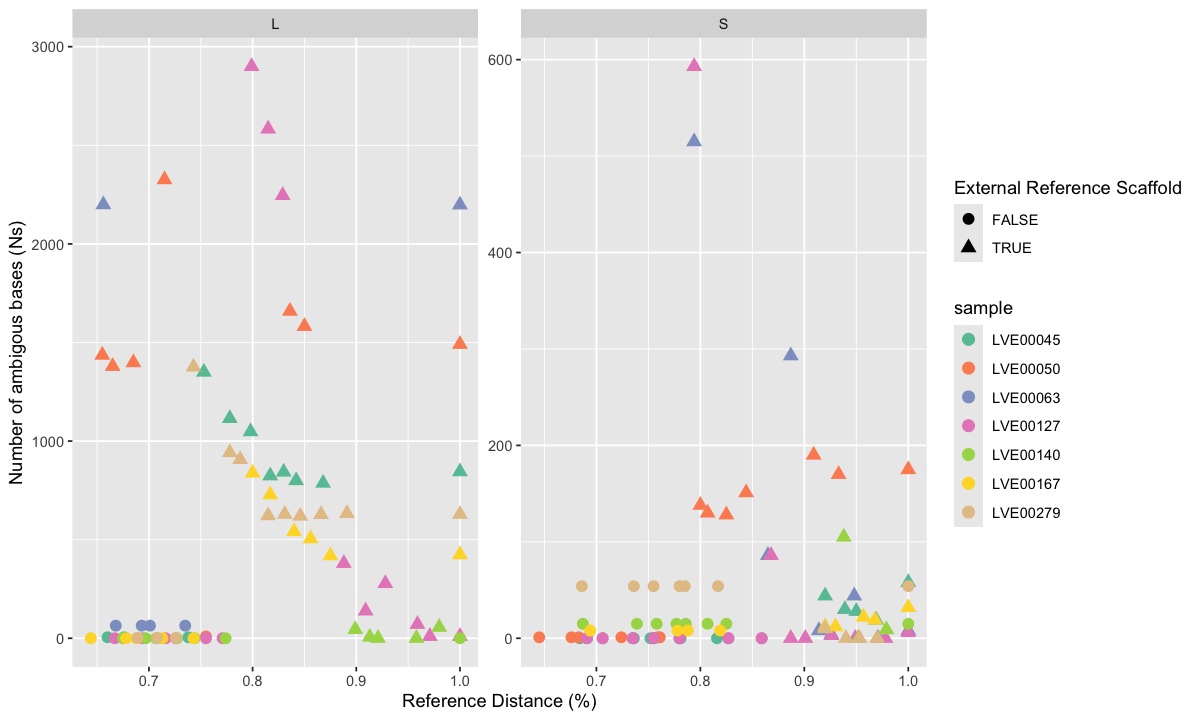

In [38]:
ggplot(consensus_vs_reference, aes(x=fident, y=seq1_Ns, color=sample, shape=is_external_reference_scaffold)) +
    geom_point(size=3) +
    facet_wrap(~segment, scales = "free") +
    labs(x="Reference Distance (%)", y="Number of ambigous bases (Ns)", color="sample", shape="External Reference Scaffold") +
    scale_color_brewer(palette = "Set2") +
    theme(plot.title = element_text(hjust = 0.5))